# Impedance Control: Pendulum with Gravity Compensation

In the previous notebook, we built an impedance controller for a mass-spring-damper — a linear, translational system. Now we extend the same principle to rotation.

**What changes:** torque replaces force, angle replaces position, angular velocity replaces linear velocity.

**What stays the same:** the impedance equation structure is identical.

**What is new:** the pendulum has a configuration-dependent gravity torque. We must compensate for it explicitly, and MuJoCo gives us `data.qfrc_bias` to do this automatically — even in multi-DOF systems where the analytical formula becomes intractable.

**Learning objectives:**
1. Recognize that rotational impedance is the same framework as translational impedance
2. Understand why gravity compensation is necessary and how `qfrc_bias` provides it
3. See the nonlinear `cos(θ)` gravity term that the MSD system did not have
4. Observe how stiffness `K` and damping `B` affect pendulum response

In [1]:
%matplotlib inline
import mujoco
import numpy as np
import matplotlib.pyplot as plt
import mediapy
print(f'MuJoCo version: {mujoco.__version__}')

MuJoCo version: 3.6.0


## Bridge from Notebook 1: Translational → Rotational Impedance

The impedance controller from Notebook 1 was:

$$F = K(x_d - x) + B(\dot{x}_d - \dot{x})$$

For the pendulum, every quantity has a rotational analogue:

| Translational (Mass-Spring-Damper, Notebook 1) | Rotational (Pendulum, Notebook 2) |
|--------------------------|-----------------------------|
| Force $F$ [N] | Torque $\tau$ [Nm] |
| Position $x$ [m] | Angle $\theta$ [rad] |
| Velocity $\dot{x}$ [m/s] | Angular velocity $\dot{\theta}$ [rad/s] |
| Mass $M$ [kg] | Inertia $I$ [kg·m²] |
| Spring stiffness $K$ [N/m] | Rotational stiffness $K$ [Nm/rad] |
| Damping $B$ [Ns/m] | Rotational damping $B$ [Nms/rad] |

The pendulum impedance law is:

$$\tau = K(\theta_d - \theta) + B(\dot{\theta}_d - \dot{\theta}) + \tau_{\text{gravity}}$$

**It is the same equation in a different coordinate, plus one new term: gravity.**

The gravity term $\tau_{\text{gravity}}$ is needed because the pendulum's equilibrium is not at $\theta = 0$ without support — gravity pulls it down. The mass-spring-damper in Notebook 1 had gravity disabled (`<option gravity="0 0 0">`), so no such term was needed.

## Why Gravity Compensation?

Consider a simple pendulum: a rod of length $L$ with a point mass $m$ at the tip. The gravitational torque about the hinge is:

$$\tau_g(\theta) = m g L \cos(\theta)$$

where $\theta = 0$ is the horizontal position (hinge axis is horizontal, pendulum swings in vertical plane).

**Why does this matter for impedance control?**

Without compensation, the equation of motion is:

$$I\ddot{\theta} = K(\theta_d - \theta) + B(\dot{\theta}_d - \dot{\theta}) - m g L \cos(\theta)$$

At steady state ($\ddot{\theta} = \dot{\theta} = 0$, $\theta_d$ constant):

$$0 = K(\theta_d - \theta_{ss}) - m g L \cos(\theta_{ss})$$

$$\theta_{ss} \approx \theta_d - \frac{m g L \cos(\theta_d)}{K}$$

There is a **steady-state error** proportional to the gravity torque divided by stiffness.

**With gravity compensation**, we add $\tau_g$ to the controller output:

$$\tau_{\text{ctrl}} = K(\theta_d - \theta) + B(\dot{\theta}_d - \dot{\theta}) + m g L \cos(\theta)$$

Now at steady state the gravity term cancels and $\theta_{ss} = \theta_d$ exactly.

**MuJoCo's shortcut:** For multi-DOF systems, computing $\tau_g$ analytically requires full rigid-body dynamics. MuJoCo computes gravity + Coriolis + centrifugal forces via the Recursive Newton-Euler algorithm and stores the result in `data.qfrc_bias`. We simply read it.

## MJCF Pendulum Model

The pendulum is defined in `models/pendulum.xml`. We load it from file — open the XML to see annotated comments on every element.

Key MJCF choices:
- `joint type="hinge" axis="0 1 0"`: rotation in the X-Z plane (pendulum swings forward/backward)
- `actuator motor`: control input is torque in Nm (same philosophy as NB1 — ctrl = torque directly)
- `armature="0.01"`: small rotor inertia for numerical stability
- `damping="0.05"`: small joint damping (friction)

In [7]:
import pathlib
import dms
# Load MJCF model from file
model_path = dms.get_asset_path('mujoco_models/pendulum.xml')
model = mujoco.MjModel.from_xml_path(model_path)
data = mujoco.MjData(model)

# Physical parameters (for analytical formulas)
L = 0.5   # rod length [m]
m = 1.0   # tip mass [kg]
g = 9.81  # gravitational acceleration [m/s^2]

# Display the XML for reference
print('---')
print(f'Timestep: {model.opt.timestep} s')
print(f'Gravity: {model.opt.gravity}')
print(f'Number of DOF (nv): {model.nv}')
print(f'Number of actuators (nu): {model.nu}')

---
Timestep: 0.001 s
Gravity: [ 0.    0.   -9.81]
Number of DOF (nv): 1
Number of actuators (nu): 1


## Gravity Compensation: Analytical vs MuJoCo

The analytical gravity torque about the hinge is $\tau_g(\theta) = -m g L \cos(\theta)$.

MuJoCo computes the same quantity via the full rigid-body dynamics equations and stores it in `data.qfrc_bias`. Let's verify they agree.

`mujoco.mj_forward(model, data)` runs the kinematics and dynamics (but not integration), so after calling it, `data.qfrc_bias` reflects the current `data.qpos`.

**Note:** `data.qfrc_bias` is the generalized force due to gravity + Coriolis + centrifugal. For a simple pendulum, Coriolis is zero, so it is purely gravity.

In [8]:
# Test angles: 0 (horizontal), 30, 45, 60, 90 degrees (vertical hanging)
test_angles_deg = [0, 30, 45, 60, 90]
test_angles_rad = np.deg2rad(test_angles_deg)

print(f'{"Angle (deg)":>12}  {"Analytical tau_g":>18}  {"MuJoCo qfrc_bias":>18}  {"Difference":>12}')
print('-' * 68)

for theta, theta_deg in zip(test_angles_rad, test_angles_deg):
    # Analytical: tau_g = m * g * L * cos(theta)
    tau_analytical = m * g * L * np.cos(theta)

    # MuJoCo: set qpos, call mj_forward, read qfrc_bias
    mujoco.mj_resetData(model, data)
    data.qpos[0] = theta
    mujoco.mj_forward(model, data)
    tau_mujoco = data.qfrc_bias[0]

    diff = tau_analytical - tau_mujoco
    print(f'{theta_deg:>12}  {tau_analytical:>18.6f}  {tau_mujoco:>18.6f}  {diff:>12.2e}')

print()
print('MuJoCo computes gravity torque via the Recursive Newton-Euler algorithm.')
print('Use data.qfrc_bias in your controller -- it handles multi-DOF systems')
print('where the analytical formula becomes intractable.')

 Angle (deg)    Analytical tau_g    MuJoCo qfrc_bias    Difference
--------------------------------------------------------------------
           0            4.905000           -4.907452      9.81e+00
          30            4.247855           -4.249979      8.50e+00
          45            3.468359           -3.470093      6.94e+00
          60            2.452500           -2.453726      4.91e+00
          90            0.000000            0.000000      3.00e-16

MuJoCo computes gravity torque via the Recursive Newton-Euler algorithm.
Use data.qfrc_bias in your controller -- it handles multi-DOF systems
where the analytical formula becomes intractable.


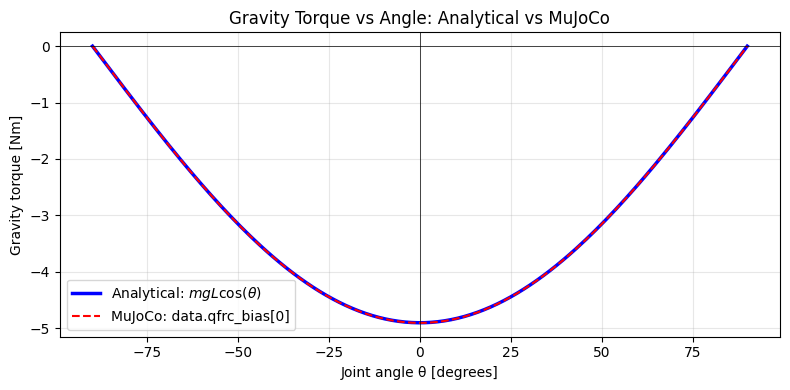

Both curves are identical — MuJoCo computes the same gravity torque as the analytical formula.


In [9]:
# Plot: gravity torque vs angle (analytical and MuJoCo overlaid)
theta_range = np.linspace(-np.pi/2, np.pi/2, 200)
tau_analytical_range = -m * g * L * np.cos(theta_range)

tau_mujoco_range = np.zeros_like(theta_range)
for i, theta in enumerate(theta_range):
    mujoco.mj_resetData(model, data)
    data.qpos[0] = theta
    mujoco.mj_forward(model, data)
    tau_mujoco_range[i] = data.qfrc_bias[0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.rad2deg(theta_range), tau_analytical_range, 'b-', linewidth=2.5, label='Analytical: $m g L \\cos(\\theta)$')
ax.plot(np.rad2deg(theta_range), tau_mujoco_range, 'r--', linewidth=1.5, label='MuJoCo: data.qfrc_bias[0]')
ax.set_xlabel('Joint angle θ [degrees]')
ax.set_ylabel('Gravity torque [Nm]')
ax.set_title('Gravity Torque vs Angle: Analytical vs MuJoCo')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()
print('Both curves are identical — MuJoCo computes the same gravity torque as the analytical formula.')

## Pendulum Impedance Controller

The controller implements:

$$\tau_{\text{impedance}} = K(\theta_d - \theta) + B(\dot{\theta}_d - \dot{\theta})$$

$$\tau_{\text{ctrl}} = \tau_{\text{impedance}} + \tau_{\text{gravity}}$$

where $\tau_{\text{gravity}} = $ `data.qfrc_bias[0]`.

We read the current state from `data.qpos[0]` (angle) and `data.qvel[0]` (angular velocity), compute the impedance torque, add gravity compensation, and write to `data.ctrl[0]` before calling `mj_step`.

In [10]:
def pendulum_impedance_controller(model, data, theta_d, omega_d, K, B):
    """Pendulum impedance controller with gravity compensation.

    Args:
        model: MjModel
        data:  MjData (qpos, qvel, qfrc_bias must be current)
        theta_d: desired angle [rad]
        omega_d: desired angular velocity [rad/s]
        K: rotational stiffness [Nm/rad]
        B: rotational damping [Nms/rad]
    """
    theta = data.qpos[0]   # current angle [rad]
    omega = data.qvel[0]   # current angular velocity [rad/s]

    # Impedance term: same equation as NB1, rotational coordinates
    tau_impedance = K * (theta_d - theta) + B * (omega_d - omega)

    # Gravity compensation: MuJoCo's qfrc_bias includes gravity + Coriolis.
    # For a simple pendulum, Coriolis is zero. For multi-DOF, it handles everything.
    tau_gravity = data.qfrc_bias[0]

    # Total control torque — set BEFORE mj_step
    data.ctrl[0] = tau_impedance + tau_gravity

## Experiment 1: Swing to Angle and Hold

The pendulum starts hanging at $\theta = 0$ (horizontal). At $t = 0.5\,\text{s}$, we command it to move to $\theta_d = 45°$ and hold there.

**Gains:** $K = 20\,\text{Nm/rad}$, $B = 2\,\text{Nms/rad}$

**Expected behavior:** The pendulum swings toward 45°, overshoots slightly (depending on $B$), then settles. With gravity compensation, the steady-state angle should be exactly 45°.

We follow the canonical simulation loop from Notebook 1: pre-allocate arrays, set `ctrl` before `mj_step`, record state after.

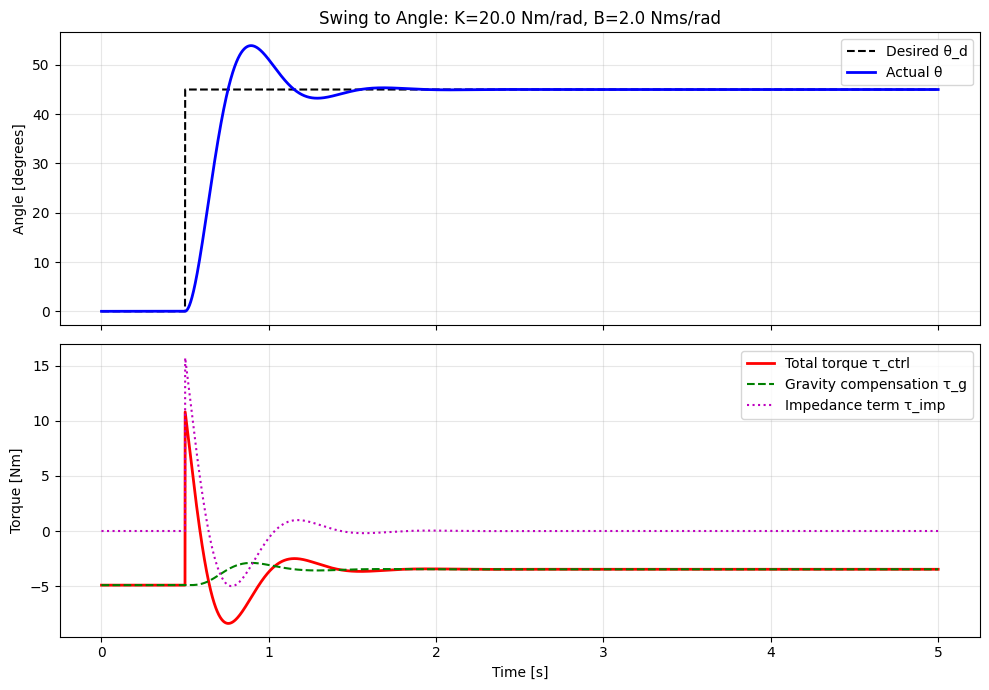

Final angle: 45.00 degrees (target: 45.0 degrees)
Steady-state error: 0.000 degrees


In [11]:
# Experiment 1 parameters
K_nom = 20.0   # rotational stiffness [Nm/rad]
B_nom = 2.0    # rotational damping [Nms/rad]
theta_target = np.pi / 4  # 45 degrees [rad]
step_time = 0.5           # step command at t=0.5s
duration = 5.0            # simulation duration [s]

n_steps = int(duration / model.opt.timestep)

# Pre-allocate recording arrays
t_log   = np.zeros(n_steps)
q_log   = np.zeros(n_steps)  # actual angle [rad]
qd_log  = np.zeros(n_steps)  # desired angle [rad]
tau_log = np.zeros(n_steps)  # total control torque [Nm]
tau_g_log = np.zeros(n_steps)  # gravity compensation torque [Nm]

mujoco.mj_resetData(model, data)
data.qpos[0] = 0.0  # start horizontal

for i in range(n_steps):
    # Desired angle: step from 0 to target at step_time
    theta_d = theta_target if data.time >= step_time else 0.0

    # Gravity torque for logging (read after mj_forward inside mj_step)
    # We need qfrc_bias current — call mj_forward first
    mujoco.mj_forward(model, data)
    tau_g_now = data.qfrc_bias[0]

    # Apply impedance controller (sets data.ctrl[0]) BEFORE mj_step
    pendulum_impedance_controller(model, data, theta_d, 0.0, K_nom, B_nom)

    # Step simulation
    mujoco.mj_step(model, data)

    # Record state
    t_log[i]   = data.time
    q_log[i]   = data.qpos[0]
    qd_log[i]  = theta_d
    tau_log[i] = data.ctrl[0]
    tau_g_log[i] = tau_g_now

# Plot results
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(t_log, np.rad2deg(qd_log), 'k--', linewidth=1.5, label='Desired θ_d')
axes[0].plot(t_log, np.rad2deg(q_log), 'b-', linewidth=2, label='Actual θ')
axes[0].set_ylabel('Angle [degrees]')
axes[0].set_title(f'Swing to Angle: K={K_nom} Nm/rad, B={B_nom} Nms/rad')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_log, tau_log, 'r-', linewidth=2, label='Total torque τ_ctrl')
axes[1].plot(t_log, tau_g_log, 'g--', linewidth=1.5, label='Gravity compensation τ_g')
axes[1].plot(t_log, tau_log - tau_g_log, 'm:', linewidth=1.5, label='Impedance term τ_imp')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Torque [Nm]')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

final_angle_deg = np.rad2deg(q_log[-1])
print(f'Final angle: {final_angle_deg:.2f} degrees (target: {np.rad2deg(theta_target):.1f} degrees)')
print(f'Steady-state error: {final_angle_deg - np.rad2deg(theta_target):.3f} degrees')

## Experiment 2: Sinusoidal Angle Tracking

Now we track a sinusoidal trajectory:

$$\theta_d(t) = \frac{\pi}{3} \sin(2\pi \cdot 0.3 \cdot t)$$

This is a 60° amplitude oscillation at 0.3 Hz. The desired angular velocity is the time derivative:

$$\dot{\theta}_d(t) = \frac{\pi}{3} \cdot 2\pi \cdot 0.3 \cdot \cos(2\pi \cdot 0.3 \cdot t)$$

**What to observe:** The impedance term handles the tracking error, while the gravity compensation torque varies with $\cos(\theta)$ — a nonlinear dependence on angle.

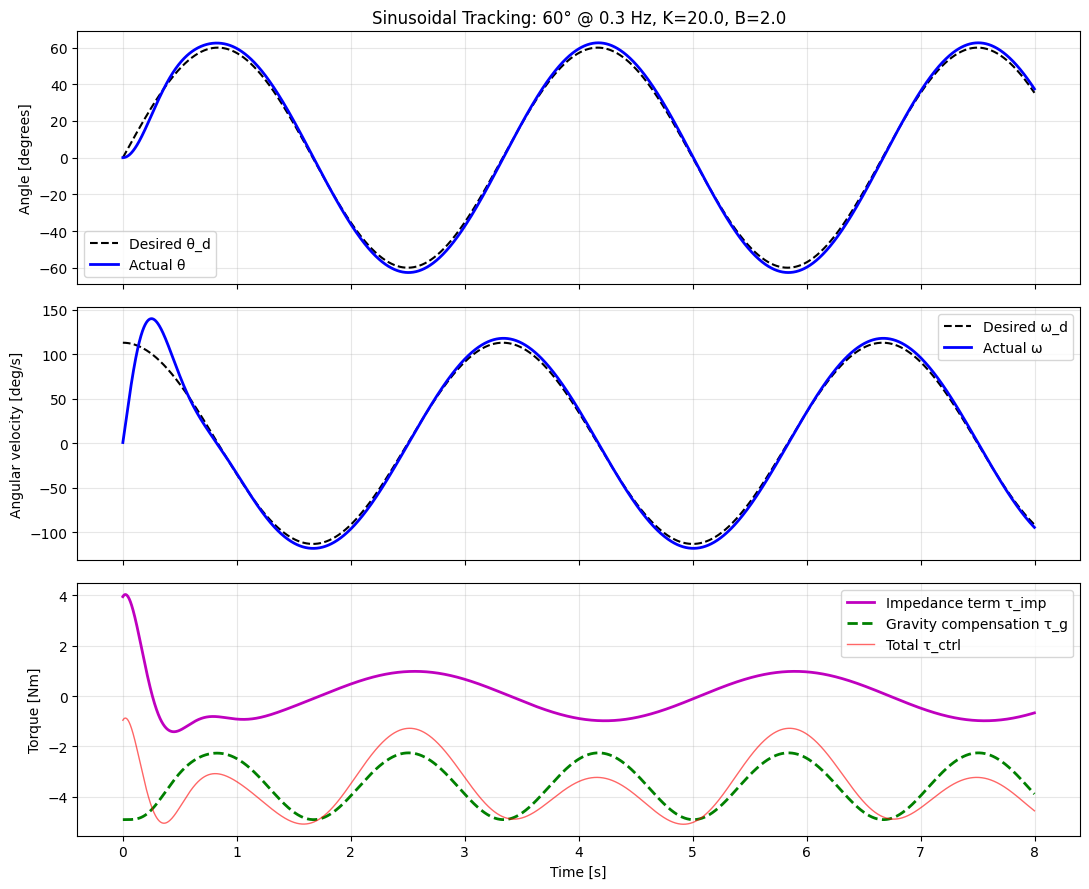

In [12]:
# Experiment 2 parameters
amp = np.pi / 3   # 60 degree amplitude [rad]
freq = 0.3        # [Hz]
duration2 = 8.0
n_steps2 = int(duration2 / model.opt.timestep)

# Pre-allocate
t2   = np.zeros(n_steps2)
q2   = np.zeros(n_steps2)
qd2  = np.zeros(n_steps2)
dq2  = np.zeros(n_steps2)   # actual angular velocity
dqd2 = np.zeros(n_steps2)   # desired angular velocity
tau_total2 = np.zeros(n_steps2)
tau_g2     = np.zeros(n_steps2)
tau_imp2   = np.zeros(n_steps2)

mujoco.mj_resetData(model, data)

for i in range(n_steps2):
    t_now = data.time
    theta_d  = amp * np.sin(2 * np.pi * freq * t_now)
    omega_d  = amp * 2 * np.pi * freq * np.cos(2 * np.pi * freq * t_now)

    mujoco.mj_forward(model, data)
    tau_g_now = data.qfrc_bias[0]

    pendulum_impedance_controller(model, data, theta_d, omega_d, K_nom, B_nom)
    tau_imp_now = data.ctrl[0] - tau_g_now

    mujoco.mj_step(model, data)

    t2[i]       = t_now
    q2[i]       = data.qpos[0]
    qd2[i]      = theta_d
    dq2[i]      = data.qvel[0]
    dqd2[i]     = omega_d
    tau_total2[i] = data.ctrl[0]
    tau_g2[i]   = tau_g_now
    tau_imp2[i] = tau_imp_now

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes[0].plot(t2, np.rad2deg(qd2), 'k--', linewidth=1.5, label='Desired θ_d')
axes[0].plot(t2, np.rad2deg(q2), 'b-', linewidth=2, label='Actual θ')
axes[0].set_ylabel('Angle [degrees]')
axes[0].set_title(f'Sinusoidal Tracking: {np.rad2deg(amp):.0f}° @ {freq} Hz, K={K_nom}, B={B_nom}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t2, np.rad2deg(dqd2), 'k--', linewidth=1.5, label='Desired ω_d')
axes[1].plot(t2, np.rad2deg(dq2), 'b-', linewidth=2, label='Actual ω')
axes[1].set_ylabel('Angular velocity [deg/s]')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(t2, tau_imp2, 'm-', linewidth=2, label='Impedance term τ_imp')
axes[2].plot(t2, tau_g2, 'g--', linewidth=2, label='Gravity compensation τ_g')
axes[2].plot(t2, tau_total2, 'r-', linewidth=1, alpha=0.6, label='Total τ_ctrl')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Torque [Nm]')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## What Happens Without Gravity Compensation?

We repeat the swing-to-angle experiment with $\tau_{\text{gravity}} = 0$ — only the impedance term drives the pendulum.

**Prediction:** At steady state, the impedance term must balance gravity:

$$K(\theta_d - \theta_{ss}) = m g L \cos(\theta_{ss})$$

For small errors near 45°:

$$\theta_{ss} \approx \theta_d - \frac{m g L \cos(\theta_d)}{K} = 45° - \frac{1.0 \times 9.81 \times 0.5 \times \cos(45°)}{20} \approx 45° - 17.3° = 27.7°$$

The controller "spends" stiffness fighting gravity instead of tracking the desired angle.

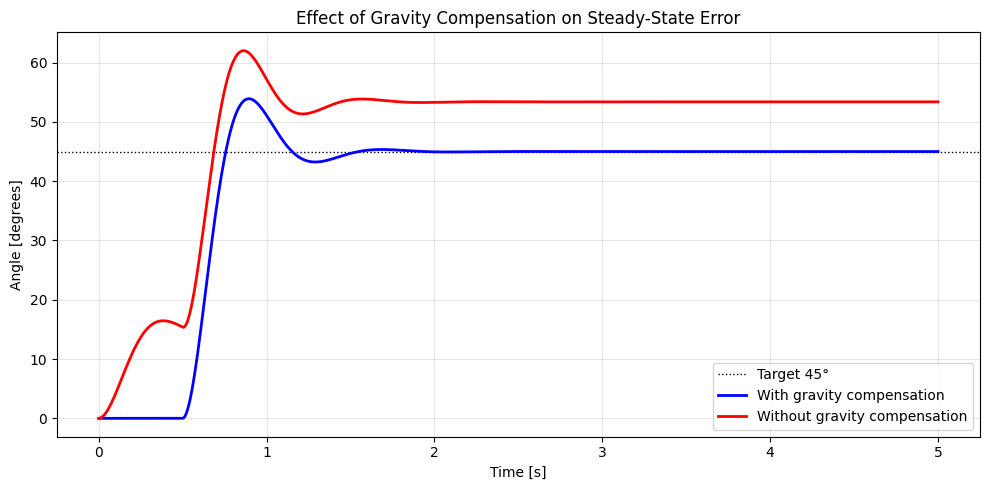

With compensation:    final angle = 45.00°
Without compensation: final angle = 53.39°
Steady-state error without compensation: -8.39°
Analytical prediction of error: ~9.94°  (= m*g*L*cos(θ_d) / K)


In [13]:
def pendulum_impedance_no_gravity(model, data, theta_d, omega_d, K, B):
    """Impedance controller WITHOUT gravity compensation (for comparison)."""
    theta = data.qpos[0]
    omega = data.qvel[0]
    # No tau_gravity term — pure impedance only
    data.ctrl[0] = K * (theta_d - theta) + B * (omega_d - omega)

# Run without gravity compensation
n_steps_nograv = int(5.0 / model.opt.timestep)
t_ng  = np.zeros(n_steps_nograv)
q_ng  = np.zeros(n_steps_nograv)

mujoco.mj_resetData(model, data)
data.qpos[0] = 0.0

for i in range(n_steps_nograv):
    theta_d = theta_target if data.time >= step_time else 0.0
    pendulum_impedance_no_gravity(model, data, theta_d, 0.0, K_nom, B_nom)
    mujoco.mj_step(model, data)
    t_ng[i] = data.time
    q_ng[i] = data.qpos[0]

# Analytical steady-state error prediction
tau_g_at_target = m * g * L * np.cos(theta_target)
predicted_error_deg = np.rad2deg(tau_g_at_target / K_nom)

fig, ax = plt.subplots(figsize=(10, 5))
ax.axhline(np.rad2deg(theta_target), color='k', linestyle=':', linewidth=1, label='Target 45°')
ax.plot(t_log, np.rad2deg(q_log), 'b-', linewidth=2, label='With gravity compensation')
ax.plot(t_ng,  np.rad2deg(q_ng),  'r-', linewidth=2, label='Without gravity compensation')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Angle [degrees]')
ax.set_title('Effect of Gravity Compensation on Steady-State Error')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

final_ng_deg = np.rad2deg(q_ng[-1])
print(f'With compensation:    final angle = {np.rad2deg(q_log[-1]):.2f}°')
print(f'Without compensation: final angle = {final_ng_deg:.2f}°')
print(f'Steady-state error without compensation: {np.rad2deg(theta_target) - final_ng_deg:.2f}°')
print(f'Analytical prediction of error: ~{predicted_error_deg:.2f}°  (= m*g*L*cos(θ_d) / K)')

## Parameter Sweep

### Effect of Stiffness K

Higher $K$ means faster, stiffer response (and higher force). For the pendulum, we also need adequate $K$ to overcome gravity — but gravity compensation eliminates that constraint.

We hold $B = 2\,\text{Nms/rad}$ fixed and vary $K \in \{5, 20, 50, 100\}\,\text{Nm/rad}$.

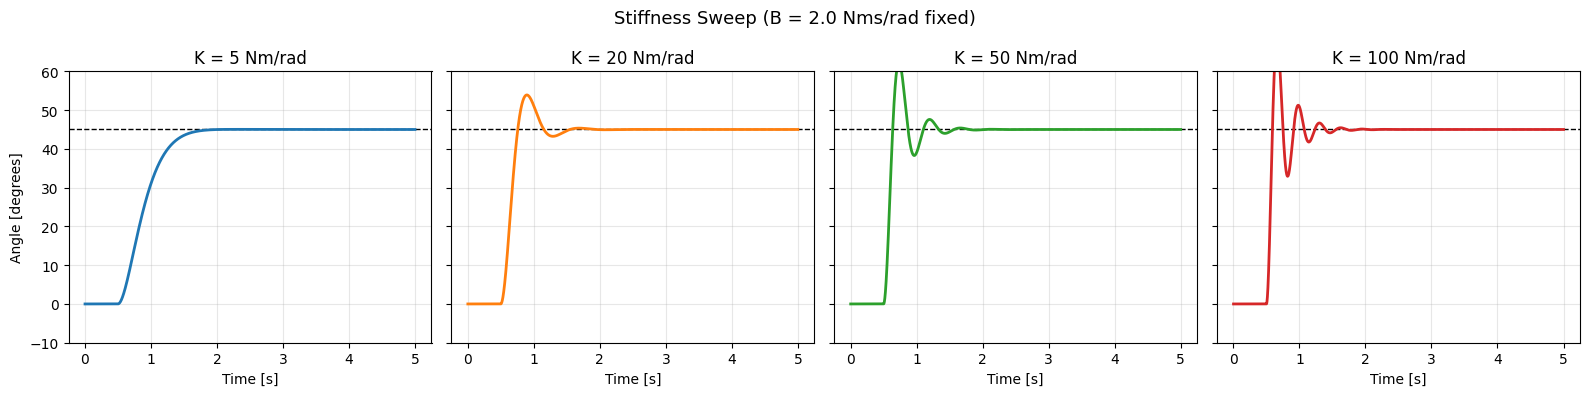

In [14]:
def run_swing_to_angle(model, K, B, theta_target=np.pi/4, step_time=0.5, duration=5.0):
    """Run swing-to-angle experiment and return (t, q) arrays."""
    data_local = mujoco.MjData(model)
    n = int(duration / model.opt.timestep)
    t_arr = np.zeros(n)
    q_arr = np.zeros(n)
    mujoco.mj_resetData(model, data_local)
    data_local.qpos[0] = 0.0
    for i in range(n):
        theta_d = theta_target if data_local.time >= step_time else 0.0
        mujoco.mj_forward(model, data_local)
        pendulum_impedance_controller(model, data_local, theta_d, 0.0, K, B)
        mujoco.mj_step(model, data_local)
        t_arr[i] = data_local.time
        q_arr[i] = data_local.qpos[0]
    return t_arr, q_arr

# Stiffness sweep
K_values = [5, 20, 50, 100]
B_fixed  = 2.0
colors_K = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, K_val, col in zip(axes, K_values, colors_K):
    t_s, q_s = run_swing_to_angle(model, K_val, B_fixed)
    ax.axhline(np.rad2deg(np.pi/4), color='k', linestyle='--', linewidth=1, label='Target 45°')
    ax.plot(t_s, np.rad2deg(q_s), color=col, linewidth=2)
    ax.set_title(f'K = {K_val} Nm/rad')
    ax.set_xlabel('Time [s]')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-10, 60)
axes[0].set_ylabel('Angle [degrees]')
fig.suptitle(f'Stiffness Sweep (B = {B_fixed} Nms/rad fixed)', fontsize=13)
plt.tight_layout()
plt.show()

### Effect of Damping B

Higher $B$ damps oscillations (reduces overshoot and ringing). At low $B$, the pendulum rings. At high $B$, it is overdamped and sluggish.

We hold $K = 20\,\text{Nm/rad}$ fixed and vary $B \in \{0.5, 2, 5, 10\}\,\text{Nms/rad}$.

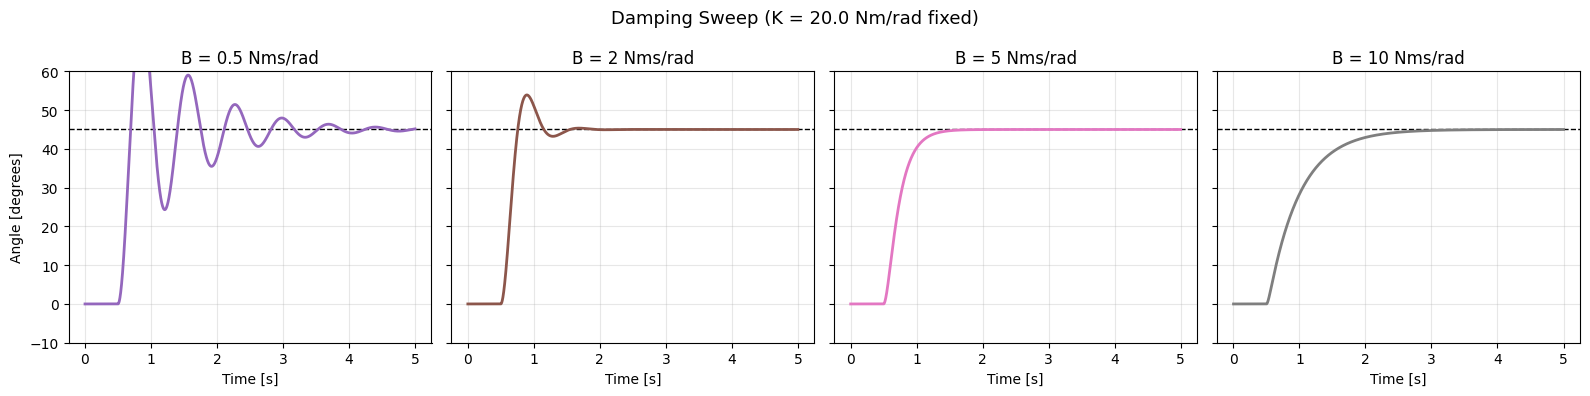

In [15]:
# Damping sweep
B_values = [0.5, 2, 5, 10]
K_fixed  = 20.0
colors_B = ['#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, B_val, col in zip(axes, B_values, colors_B):
    t_s, q_s = run_swing_to_angle(model, K_fixed, B_val)
    ax.axhline(np.rad2deg(np.pi/4), color='k', linestyle='--', linewidth=1, label='Target 45°')
    ax.plot(t_s, np.rad2deg(q_s), color=col, linewidth=2)
    ax.set_title(f'B = {B_val} Nms/rad')
    ax.set_xlabel('Time [s]')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-10, 60)
axes[0].set_ylabel('Angle [degrees]')
fig.suptitle(f'Damping Sweep (K = {K_fixed} Nm/rad fixed)', fontsize=13)
plt.tight_layout()
plt.show()

## Nonlinearity Visualization

Unlike the mass-spring-damper where spring force is linear in displacement ($F = K x$), the pendulum's gravity term is **nonlinear**:

$$\tau_g(\theta) = m g L \cos(\theta)$$

This means the compensation torque changes shape as the pendulum oscillates — it is not a simple rescaling of $\theta$.

Below we plot the angle trajectory from the sinusoidal experiment alongside the gravity torque. Notice that the gravity curve has a **cosine shape** while the angle has a **sine shape** — they are 90° out of phase, reflecting the $\cos(\theta)$ nonlinearity.

**This is why `qfrc_bias` matters:** it recomputes this nonlinear term every timestep without any approximation.

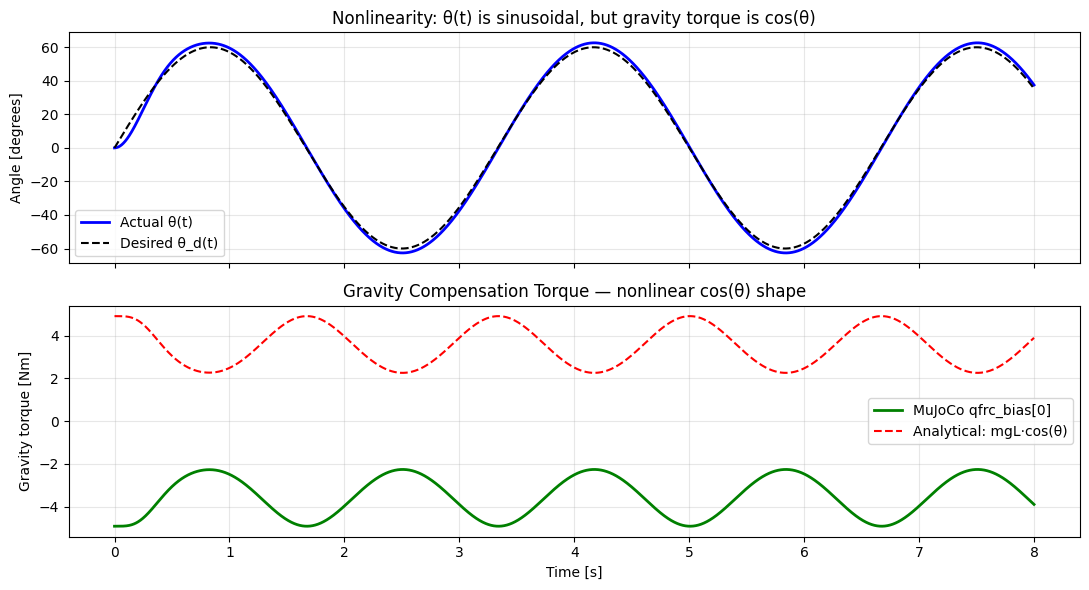

Unlike the MSD where forces are linear in displacement,
the pendulum gravity term is nonlinear.
qfrc_bias adapts every timestep — no linear approximation needed.


In [16]:
# Use sinusoidal tracking data from Experiment 2
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(t2, np.rad2deg(q2), 'b-', linewidth=2, label='Actual θ(t)')
axes[0].plot(t2, np.rad2deg(qd2), 'k--', linewidth=1.5, label='Desired θ_d(t)')
axes[0].set_ylabel('Angle [degrees]')
axes[0].set_title('Nonlinearity: θ(t) is sinusoidal, but gravity torque is cos(θ)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Analytical gravity torque along the actual trajectory
tau_g_analytical_traj = m * g * L * np.cos(q2)

axes[1].plot(t2, tau_g2, 'g-', linewidth=2, label='MuJoCo qfrc_bias[0]')
axes[1].plot(t2, tau_g_analytical_traj, 'r--', linewidth=1.5, label='Analytical: mgL·cos(θ)')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Gravity torque [Nm]')
axes[1].set_title('Gravity Compensation Torque — nonlinear cos(θ) shape')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Unlike the MSD where forces are linear in displacement,')
print('the pendulum gravity term is nonlinear.')
print('qfrc_bias adapts every timestep — no linear approximation needed.')

## Inline Video

We render the swing-to-angle experiment as an inline video using `mujoco.Renderer` and `mediapy`.

In [17]:
video_duration = 5.0
fps = 30
n_video = int(video_duration / model.opt.timestep)
render_every = int(1.0 / (fps * model.opt.timestep))

frames = []
renderer = mujoco.Renderer(model, height=300, width=400)

data_vid = mujoco.MjData(model)
mujoco.mj_resetData(model, data_vid)
data_vid.qpos[0] = 0.0

for i in range(n_video):
    theta_d = theta_target if data_vid.time >= step_time else 0.0
    mujoco.mj_forward(model, data_vid)
    pendulum_impedance_controller(model, data_vid, theta_d, 0.0, K_nom, B_nom)
    mujoco.mj_step(model, data_vid)
    if i % render_every == 0:
        renderer.update_scene(data_vid)
        frames.append(renderer.render())

renderer.close()
mediapy.show_video(frames, fps=fps)
print(f'Video: {len(frames)} frames at {fps} fps')


This browser does not support the video tag.


Video: 152 frames at 30 fps


## Summary and What's Next

### Key Takeaways

1. **Rotational impedance is the same framework as translational.** The controller equation $\tau = K(\theta_d - \theta) + B(\dot{\theta}_d - \dot{\theta})$ is structurally identical to the mass-spring-damper controller — only the units and physical meaning change.

2. **Gravity compensation is necessary.** Without it, the impedance controller has a steady-state error of $\approx m g L \cos(\theta_d) / K$. With `data.qfrc_bias`, this error is eliminated.

3. **`data.qfrc_bias` is the practical choice for gravity compensation.** It is computed by MuJoCo's Recursive Newton-Euler algorithm and works for any number of DOFs — no manual derivation required.

4. **Bias terms are nonlinear.** The $\cos(\theta)$ dependence means the compensation torque is not a linear function of angle. The controller re-reads `qfrc_bias` every timestep, so no linearization is needed.

5. **The `K` and `B` tradeoffs from Notebook 1 still apply.** Higher $K$ means faster convergence but more torque; higher $B$ reduces overshoot but slows response.

### What's Next

We have now seen impedance control in 1D (translational) and 1-DOF rotational systems. In the next notebook, we extend to **coupled multi-DOF systems** — a 2-link arm — where the stiffness $K$ and damping $B$ become **matrices**, and gravity compensation extends to a vector of joint torques computed from the full Jacobian. The `qfrc_bias` vector grows from 1 element to $n$ elements, and the insight from this notebook carries forward directly.